# Week 05 Lab Work

**Dataset:** Adult / Census Income (UCI Machine Learning Repository) - `adult.data` and `adult.test`

1. Load the data using pandas.
2. Find the missing data.
3. Fill the missing data using an automatic technique.
4. Find the noisy data.
5. Handle the noisy data using an automatic technique.
6. Integrate the data from multiple sources.

The same dataset from Week 04 is used. Week 04 threw the incomplete records away with
`dropna()`. This lab keeps them, because the missing values are the subject of tasks 2 and 3.

## 1. Load the dataset

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler

cols = ["age", "workclass", "fnlwgt", "education", "education-num",
        "marital-status", "occupation", "relationship", "race", "sex",
        "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]


def get_file(data_filename):
    """Find the file in the workspace, otherwise download it from the UCI repository."""
    for base in [".", ".."]:
        if not os.path.isdir(base):
            continue
        for root, dirs, files in os.walk(base):
            if data_filename in files:
                return os.path.join(root, data_filename)

    print(f"'{data_filename}' not found in the workspace. Downloading it dynamically...")
    url = f"https://archive.ics.uci.edu/ml/machine-learning-databases/adult/{data_filename}"
    try:
        urllib.request.urlretrieve(url, data_filename)
        print("Download complete!")
        return data_filename
    except Exception as e:
        raise FileNotFoundError(
            f"Could not download the file automatically. Please manually upload '{data_filename}' "
            "to the Colab file explorer panel on the left."
        ) from e


target_path = get_file("adult.data")
print(f"Loading dataset from: {target_path}")

df = pd.read_csv(target_path, header=None, names=cols,
                 skipinitialspace=True, na_values="?")
df.shape

Loading dataset from: ../Task_No_3 (week 4)/adult dataset/adult.data


(32561, 15)

In [2]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
numeric = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical = [c for c in cols if c not in numeric]

# `education-num` is an ordinal code, not a measurement, so it is left out of the noise handling
noise_cols = ["age", "fnlwgt", "capital-gain", "capital-loss", "hours-per-week"]

print("numeric    :", numeric)
print("categorical:", categorical)
print("noise_cols :", noise_cols)
df.dtypes

numeric    : ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
noise_cols : ['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']


age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

## 2. Find the missing data

In this dataset a missing value is written as `?`. `read_csv(na_values="?")` turns every `?`
into `NaN`, so `isna()` can count them.

In [4]:
missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percent": (df.isna().mean() * 100).round(2),
})
display(missing[missing["missing"] > 0])

print("total missing cells        :", int(df.isna().sum().sum()))
print("rows with a missing value  :", int(df.isna().any(axis=1).sum()))
print("percent of rows affected   :", round(df.isna().any(axis=1).mean() * 100, 2))

,missing,percent
workclass,1836,5.64
occupation,1843,5.66
native-country,583,1.79


total missing cells        : 4262
rows with a missing value  : 2399
percent of rows affected   : 7.37


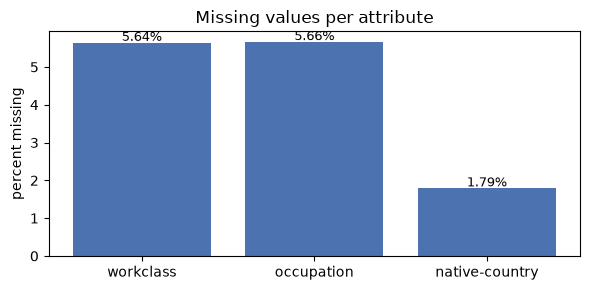

In [5]:
affected = missing[missing["missing"] > 0]

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(affected.index, affected["percent"], color="#4c72b0")
ax.set_ylabel("percent missing")
ax.set_title("Missing values per attribute")
for i, v in enumerate(affected["percent"]):
    ax.text(i, v + 0.05, f"{v}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Pattern of the missing values

`workclass` and `occupation` are almost always missing together: a record with no employer
also has no job title. This is a **structured** pattern, not a random one.

In [6]:
pattern = pd.crosstab(df["workclass"].isna(), df["occupation"].isna(),
                      rownames=["workclass missing"], colnames=["occupation missing"])
display(pattern)

df[df["workclass"].isna()].head(3)[["age", "workclass", "occupation", "native-country", "income"]]

occupation missing,False,True
workclass missing,,
False,30718,7
True,0,1836


,age,workclass,occupation,native-country,income
27,54,NaN,NaN,South,>50K
61,32,NaN,NaN,NaN,<=50K
69,25,NaN,NaN,United-States,<=50K


## 3. Fill the missing data (automatic technique)

All three attributes with missing values are nominal, so the automatic technique is
`SimpleImputer(strategy="most_frequent")` from scikit-learn. The imputer learns the mode of
every column with `fit` and writes it into the empty cells with `transform`.

The same fitted imputer is re-used on the second data source in task 6, so both sources are
filled with the same values.

In [7]:
missing_cols = list(affected.index)

imputer = SimpleImputer(strategy="most_frequent")
imputer.fit(df[missing_cols])

filled = df.copy()
filled[missing_cols] = imputer.transform(df[missing_cols])

print("value used to fill each column:")
for c, v in zip(missing_cols, imputer.statistics_):
    print(f"  {c:<15} -> {v}")

print("\nmissing cells before:", int(df.isna().sum().sum()))
print("missing cells after :", int(filled.isna().sum().sum()))

value used to fill each column:
  workclass       -> Private
  occupation      -> Prof-specialty
  native-country  -> United-States

missing cells before: 4262
missing cells after : 0


In [8]:
before = df["occupation"].value_counts().rename("before")
after = filled["occupation"].value_counts().rename("after")
compare = pd.concat([before, after], axis=1).fillna(0).astype(int)
compare["added"] = compare["after"] - compare["before"]
compare.sort_values("added", ascending=False).head(5)

,before,after,added
occupation,,,
Prof-specialty,4140,5983,1843
Craft-repair,4099,4099,0
Exec-managerial,4066,4066,0
Adm-clerical,3770,3770,0
Sales,3650,3650,0


### 3.2 Numeric imputation, checked with a controlled test

No numeric column of this dataset has missing values, so the numeric technique cannot be
measured on the raw file. To measure it, 5 % of a column is hidden on purpose, filled with
`KNNImputer` (k = 5), and the filled values are compared with the true values that were
hidden. Filling with the column mean is the baseline to beat.

The columns are min-max scaled first, because `KNNImputer` uses a distance: without scaling
`fnlwgt` (range ~1.5 million) would decide every neighbour on its own.

In [9]:
rng = np.random.default_rng(42)
scores = []

for target in ["age", "hours-per-week"]:
    mask = rng.random(len(filled)) < 0.05
    truth = filled.loc[mask, target].to_numpy(dtype=float)

    holed = filled[numeric].astype(float).copy()
    holed.loc[mask, target] = np.nan

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(holed)
    repaired = pd.DataFrame(scaler.inverse_transform(KNNImputer(n_neighbors=5).fit_transform(scaled)),
                            columns=numeric, index=holed.index)

    knn_guess = repaired.loc[mask, target].to_numpy()
    mean_guess = np.full_like(truth, filled.loc[~mask, target].mean())
    scores.append({
        "attribute": target,
        "values hidden": int(mask.sum()),
        "MAE, KNN k=5": round(np.abs(knn_guess - truth).mean(), 3),
        "MAE, mean filling": round(np.abs(mean_guess - truth).mean(), 3),
    })

pd.DataFrame(scores).set_index("attribute")

,values hidden,"MAE, KNN k=5","MAE, mean filling"
attribute,,,
age,1634,10.984,11.435
hours-per-week,1624,8.638,7.646


KNN wins on `age` and loses on `hours-per-week`. KNN only helps when the column can be
predicted from its neighbours, and `hours-per-week` cannot: 47 % of the records are exactly
40, so one constant is already a very strong answer. A technique must be measured, not
assumed.

## 4. Find the noisy data

Noise is a random error in a measured value. Three kinds are looked for:

1. duplicated records,
2. numeric outliers, found with the IQR rule and with the z-score,
3. sentinel values, a single value that stands for "top of the scale" instead of a real number.

In [10]:
dupes = filled.duplicated().sum()
print("duplicated rows:", int(dupes))
display(filled[filled.duplicated(keep=False)].sort_values(cols).head(4))

duplicated rows: 24


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [11]:
filled[numeric].describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00


In [12]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


report = []
for c in numeric:
    lo, hi = iqr_bounds(filled[c])
    z = (filled[c] - filled[c].mean()) / filled[c].std()
    report.append({
        "attribute": c,
        "low bound": round(lo, 2),
        "high bound": round(hi, 2),
        "IQR outliers": int(((filled[c] < lo) | (filled[c] > hi)).sum()),
        "z-score > 3": int((z.abs() > 3).sum()),
    })

noise_report = pd.DataFrame(report).set_index("attribute")
noise_report

,low bound,high bound,IQR outliers,z-score > 3
attribute,,,,
age,-2.0,78.0,143,121
fnlwgt,-61009.0,415887.0,992,347
education-num,4.5,16.5,1198,219
capital-gain,0.0,0.0,2712,215
capital-loss,0.0,0.0,1519,1470
hours-per-week,32.5,52.5,9008,440


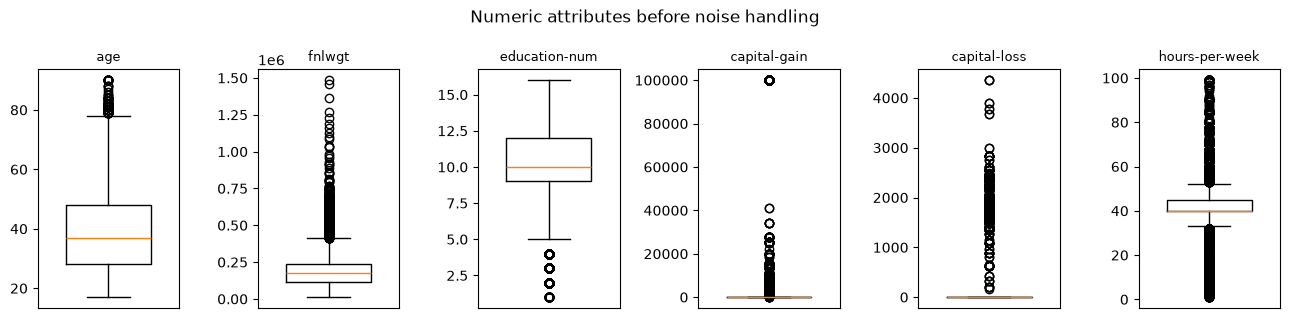

In [13]:
fig, axes = plt.subplots(1, len(numeric), figsize=(13, 3.2))
for ax, c in zip(axes, numeric):
    ax.boxplot(filled[c], widths=0.6)
    ax.set_title(c, fontsize=9)
    ax.set_xticks([])
plt.suptitle("Numeric attributes before noise handling")
plt.tight_layout()
plt.show()

### Sentinel value

`capital-gain` has a large group of records with exactly 99999. That is the code the census
used for "99999 or more", so it is a censored value, not a measurement.

In [14]:
top = filled["capital-gain"].value_counts().head(5)
display(top)
print("records at 99999:", int((filled["capital-gain"] == 99999).sum()))
print("next highest value:", int(filled.loc[filled["capital-gain"] < 99999, "capital-gain"].max()))

capital-gain
0        29849
15024      347
7688       284
7298       246
99999      159
Name: count, dtype: int64

records at 99999: 159
next highest value: 41310


## 5. Handle the noisy data (automatic technique)

Two automatic techniques are used:

| Step | Technique | Attributes |
|---|---|---|
| 5.1 | Drop duplicated tuples | all |
| 5.2 | Percentile capping (winsorising): every value below the 1st percentile or above the 99th is moved to that bound | `noise_cols` |
| 5.3 | Binning, smoothing by bin means: equal-frequency bins, every value replaced by the mean of its bin | `age`, `hours-per-week` |

Capping keeps the record and only removes the extreme size of the value, so no row is lost.
Binning removes the small random error inside a bin.

**Why the 1.5 IQR fence is used to find outliers but not to cap them.** Three of these
attributes are strongly skewed. `capital-gain` is 0 for 92 % of the records, so its quartiles
are both 0 and the fence is the single point $[0, 0]$: capping on that fence would set the
whole column to 0 and destroy the attribute. The 1st and 99th percentile are a safe automatic
bound for skewed data, and they also pull the 99999 sentinel back to a real value.

In [15]:
clean = filled.drop_duplicates().reset_index(drop=True)
print("rows before:", len(filled))
print("rows after :", len(clean))
print("removed    :", len(filled) - len(clean))

rows before: 32561
rows after : 32537
removed    : 24


In [16]:
bounds = {c: tuple(clean[c].quantile([0.01, 0.99])) for c in noise_cols}
capped_counts = {}
old_range = clean[noise_cols].agg(["min", "max"]).T

for c, (lo, hi) in bounds.items():
    capped_counts[c] = int(((clean[c] < lo) | (clean[c] > hi)).sum())
    clean[c] = clean[c].clip(lower=lo, upper=hi)

pd.DataFrame({
    "1st pct": pd.Series({c: v[0] for c, v in bounds.items()}),
    "99th pct": pd.Series({c: v[1] for c, v in bounds.items()}),
    "values capped": pd.Series(capped_counts),
    "old min": old_range["min"], "old max": old_range["max"],
    "new min": clean[noise_cols].min(), "new max": clean[noise_cols].max(),
})

,1st pct,99th pct,values capped,old min,old max,new min,new max
age,17.00,74.0,285,17,90,17.00,74.0
fnlwgt,27185.08,510072.0,651,12285,1484705,27185.08,510072.0
capital-gain,0.00,15024.0,261,0,99999,0.00,15024.0
capital-loss,0.00,1980.0,325,0,4356,0.00,1980.0
hours-per-week,8.00,80.0,503,1,99,8.00,80.0


In [17]:
def smooth_by_bin_means(s, n_bins=10):
    bins = pd.qcut(s, n_bins, duplicates="drop")
    return s.groupby(bins, observed=True).transform("mean").round(2)


for c in ["age", "hours-per-week"]:
    clean[c + "-smooth"] = smooth_by_bin_means(clean[c])

demo = clean[["age", "age-smooth", "hours-per-week", "hours-per-week-smooth"]].head(8)
display(demo)

print("standard deviation of age            :", round(clean["age"].std(), 3))
print("standard deviation of smoothed age   :", round(clean["age-smooth"].std(), 3))
print("distinct values, age -> smoothed age :",
      clean["age"].nunique(), "->", clean["age-smooth"].nunique())

,age,age-smooth,hours-per-week,hours-per-week-smooth
0,39,39.49,40,39.86
1,50,47.87,13,16.33
2,38,39.49,40,39.86
3,53,54.14,40,39.86
4,28,28.50,40,39.86
5,37,35.49,40,39.86
6,49,47.87,16,16.33
7,52,54.14,45,45.13


standard deviation of age            : 13.48
standard deviation of smoothed age   : 13.332
distinct values, age -> smoothed age : 58 -> 10


,max |z| before,max |z| after,at 99999 before,at 99999 after
attribute,,,,
age,3.77,2.63,0,0
fnlwgt,12.27,3.22,0,0
capital-gain,13.39,5.71,159,0
capital-loss,10.59,4.95,0,0
hours-per-week,4.74,3.32,0,0


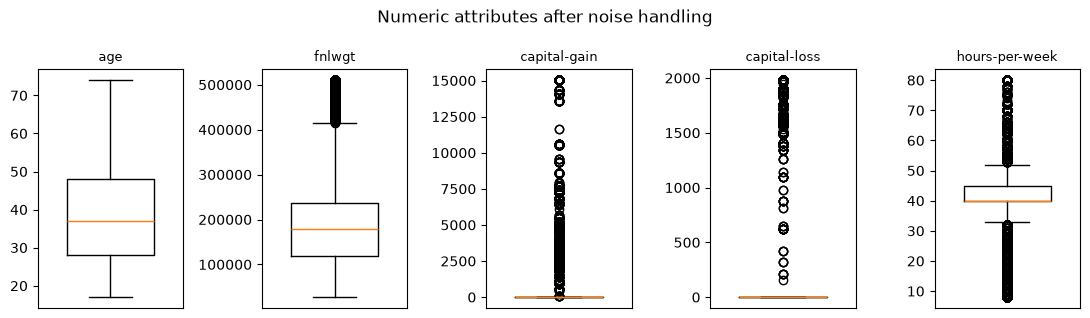

In [18]:
def max_abs_z(s):
    return round((abs(s - s.mean()) / s.std()).max(), 2)


after_report = []
for c in noise_cols:
    after_report.append({
        "attribute": c,
        "max |z| before": max_abs_z(filled[c]),
        "max |z| after": max_abs_z(clean[c]),
        "at 99999 before": int((filled[c] == 99999).sum()),
        "at 99999 after": int((clean[c] == 99999).sum()),
    })
display(pd.DataFrame(after_report).set_index("attribute"))

fig, axes = plt.subplots(1, len(noise_cols), figsize=(11, 3.2))
for ax, c in zip(axes, noise_cols):
    ax.boxplot(clean[c], widths=0.6)
    ax.set_title(c, fontsize=9)
    ax.set_xticks([])
plt.suptitle("Numeric attributes after noise handling")
plt.tight_layout()
plt.show()

## 6. Integrate the data from multiple sources

Three sources are joined:

| Source | Content | Join |
|---|---|---|
| A | `adult.data`, cleaned in tasks 1-5 | - |
| B | `adult.test`, the same schema in a different file | vertical, `concat` |
| C | a country-to-region table built in the notebook | horizontal, `merge` on `native-country` |

Four integration problems are handled: **entity identification** (the same attribute in both
files), **value conflict** (`>50K` against `>50K.`), **tuple duplication** (the same person in
both files) and **redundancy** (two attributes that carry the same information).

The largest z-score falls in every attribute, and no record is left at the 99999
sentinel. Note that the *count* of records with |z| > 3 is not a fair check here: capping
also shrinks the standard deviation, so the 3 sigma line moves inwards and can catch more
records than before. The size of the extreme value is the honest measure.

### 6.1 Source B: `adult.test`

This file has two differences from `adult.data`: the first line is not data, and every income
label ends with a full stop. Both are value conflicts and must be fixed before the merge.

In [19]:
test_path = get_file("adult.test")
print(f"Loading second source from: {test_path}")

df_b = pd.read_csv(test_path, header=None, names=cols, skiprows=1,
                   skipinitialspace=True, na_values="?")

print("\nincome labels in source A:", sorted(clean["income"].unique()))
print("income labels in source B:", sorted(df_b["income"].unique()))
df_b.shape

Loading second source from: ../Task_No_3 (week 4)/adult dataset/adult.test

income labels in source A: ['<=50K', '>50K']
income labels in source B: ['<=50K.', '>50K.']


(16281, 15)

In [20]:
df_b["income"] = df_b["income"].str.rstrip(".")
print("income labels in source B after the fix:", sorted(df_b["income"].unique()))

print("missing cells in source B before:", int(df_b.isna().sum().sum()))
df_b[missing_cols] = imputer.transform(df_b[missing_cols])
print("missing cells in source B after :", int(df_b.isna().sum().sum()))

for c, (lo, hi) in bounds.items():
    df_b[c] = df_b[c].clip(lower=lo, upper=hi)
for c in ["age", "hours-per-week"]:
    df_b[c + "-smooth"] = smooth_by_bin_means(df_b[c])

df_b.head(3)

income labels in source B after the fix: ['<=50K', '>50K']
missing cells in source B before: 2203
missing cells in source B after : 0


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age-smooth,hours-per-week-smooth
0,25,Private,226802.0,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,24.40,39.85
1,38,Private,89814.0,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,39.49,51.07
2,28,Local-gov,336951.0,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,28.52,39.85


### 6.2 Vertical integration and tuple duplication

In [21]:
clean["source"] = "adult.data"
df_b["source"] = "adult.test"

integrated = pd.concat([clean, df_b], ignore_index=True)
print("rows of source A   :", len(clean))
print("rows of source B   :", len(df_b))
print("rows after concat  :", len(integrated))

dupes_across = integrated.duplicated(subset=cols).sum()
print("tuples found in both sources:", int(dupes_across))

integrated = integrated.drop_duplicates(subset=cols).reset_index(drop=True)
print("rows after de-duplication   :", len(integrated))
display(integrated["source"].value_counts())

rows of source A   : 32537
rows of source B   : 16281
rows after concat  : 48818
tuples found in both sources: 34
rows after de-duplication   : 48784


source
adult.data    32534
adult.test    16250
Name: count, dtype: int64

### 6.3 Source C: horizontal integration on a key

A small region table is the third source. `native-country` is the join key. A left merge keeps
every record; a country with no entry in the table gets `Other`.

In [22]:
regions = pd.DataFrame({
    "native-country": [
        "United-States", "Mexico", "Canada", "Puerto-Rico", "El-Salvador", "Cuba",
        "Jamaica", "Dominican-Republic", "Guatemala", "Haiti", "Honduras", "Nicaragua",
        "Trinadad&Tobago", "Columbia", "Ecuador", "Peru", "Outlying-US(Guam-USVI-etc)",
        "India", "Philippines", "China", "Vietnam", "Japan", "Taiwan", "Iran",
        "South", "Hong", "Thailand", "Cambodia", "Laos",
        "Germany", "England", "Italy", "Poland", "Portugal", "Greece", "France",
        "Ireland", "Yugoslavia", "Scotland", "Hungary", "Holand-Netherlands",
    ],
    "region": (["North America"] * 4 + ["Central America & Caribbean"] * 9
               + ["South America"] * 3 + ["North America"] * 1
               + ["Asia"] * 12 + ["Europe"] * 12),
})
print("region table rows:", len(regions))
display(regions.head(3))

integrated = integrated.merge(regions, on="native-country", how="left")
integrated["region"] = integrated["region"].fillna("Other")

print("countries with no region entry:",
      sorted(integrated.loc[integrated["region"] == "Other", "native-country"].unique()))
integrated["region"].value_counts()

region table rows: 41


,native-country,region
0,United-States,North America
1,Mexico,North America
2,Canada,North America


countries with no region entry: []


region
North America                  45974
Asia                            1095
Europe                           780
Central America & Caribbean      759
South America                    176
Name: count, dtype: int64

### 6.4 Redundancy analysis

Redundancy is the fourth integration problem. Two tests are used:

- **numeric against numeric**: the correlation coefficient,
- **nominal against nominal**: the chi-square test of independence.

`education` and `education-num` are the same attribute written twice, and `age-smooth` is
built from `age`, so both pairs must show up as redundant.

In [23]:
corr = integrated[numeric + ["age-smooth", "hours-per-week-smooth"]].corr().round(3)
display(corr)

pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
print("strongest correlated pairs:")
display(pairs.abs().sort_values(ascending=False).head(3))

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,age-smooth,hours-per-week-smooth
age,1.000,-0.078,0.032,0.124,0.054,0.078,0.989,0.086
fnlwgt,-0.078,1.000,-0.040,-0.003,-0.003,-0.014,-0.078,-0.014
education-num,0.032,-0.040,1.000,0.168,0.081,0.149,0.031,0.158
capital-gain,0.124,-0.003,0.168,1.000,-0.055,0.106,0.124,0.111
capital-loss,0.054,-0.003,0.081,-0.055,1.000,0.056,0.054,0.059
hours-per-week,0.078,-0.014,0.149,0.106,0.056,1.000,0.088,0.967
age-smooth,0.989,-0.078,0.031,0.124,0.054,0.088,1.000,0.095
hours-per-week-smooth,0.086,-0.014,0.158,0.111,0.059,0.967,0.095,1.000


strongest correlated pairs:


age             age-smooth               0.989
hours-per-week  hours-per-week-smooth    0.967
education-num   capital-gain             0.168
dtype: float64

In [24]:
table = pd.crosstab(integrated["education"], integrated["education-num"])
chi2, p, dof, _ = chi2_contingency(table)
n = table.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

print(f"education vs education-num : chi2 = {chi2:,.0f}, p = {p:.3g}, Cramer's V = {cramers_v:.3f}")

table2 = pd.crosstab(integrated["sex"], integrated["relationship"])
chi2b, pb, _, _ = chi2_contingency(table2)
vb = np.sqrt(chi2b / (table2.to_numpy().sum() * (min(table2.shape) - 1)))
print(f"sex       vs relationship  : chi2 = {chi2b:,.0f}, p = {pb:.3g}, Cramer's V = {vb:.3f}")

education vs education-num : chi2 = 731,760, p = 0, Cramer's V = 1.000
sex       vs relationship  : chi2 = 20,406, p = 0, Cramer's V = 0.647


In [25]:
integrated = integrated.drop(columns=["education-num"])
print("`education-num` dropped: it is Cramer's V = 1.00 redundant with `education`.")

print("\nfinal shape:", integrated.shape)
print("missing cells:", int(integrated.isna().sum().sum()))
print("duplicated rows:", int(integrated.duplicated().sum()))
integrated.head()

`education-num` dropped: it is Cramer's V = 1.00 redundant with `education`.

final shape: (48784, 18)
missing cells: 0


duplicated rows: 0


,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,age-smooth,hours-per-week-smooth,source,region
0,39,State-gov,77516.0,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,39.49,39.86,adult.data,North America
1,50,Self-emp-not-inc,83311.0,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,47.87,16.33,adult.data,North America
2,38,Private,215646.0,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,39.49,39.86,adult.data,North America
3,53,Private,234721.0,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,54.14,39.86,adult.data,North America
4,28,Private,338409.0,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,28.50,39.86,adult.data,Central America & Caribbean


## Summary

| Task | Technique | Result |
|---|---|---|
| 1. Load | `pd.read_csv(..., na_values="?")` | 32,561 x 15, incomplete records kept |
| 2. Find missing | `isna()` counts per attribute | 4,262 cells in `workclass`, `occupation`, `native-country`; 2,399 rows (7.37 %) |
| 3. Fill missing | `SimpleImputer(strategy="most_frequent")` | 0 missing cells; the same fitted imputer re-used on source B |
| 3.2 Check | `KNNImputer` on a controlled 5 % hold-out | beats mean filling on `age`, loses on `hours-per-week` |
| 4. Find noise | duplicates, 1.5 IQR rule, z-score, sentinel check | 24 duplicated rows, outliers in every numeric attribute, 159 records at the 99999 cap |
| 5. Handle noise | drop duplicates, 1st/99th percentile capping, binning by bin means | 24 rows dropped, 2,025 values capped, no row lost to capping, largest z-score cut in every attribute |
| 6. Integrate | `concat` of `adult.data` + `adult.test`, `merge` with a region table | one table of 48,784 x 18: value conflicts fixed, 34 shared tuples removed, `education-num` dropped as redundant |

The four integration problems of the textbook all showed up in real form: entity
identification (the same 15 attributes in two files), value conflict (`>50K` against `>50K.`),
tuple duplication (34 records in both files) and redundancy (`education` and `education-num`
at Cramer's V = 1.00).